# Introduction

This notebook analyzes AI and ML related bachelor theses defended at the Faculty of Informatics and Statistics between 2021 and 2025. The goal is to show what students are working on, how these topics change over time, and what this says about the current AIML profile of the faculty.

The dataset was collected from the VŠKP repository and filtered to include only relevant AIML theses. After cleaning and duplicate removal, the final analytical corpus contains 59 theses.

The analysis uses mainly abstracts and keywords, because they provide a compact but useful description of each thesis. To work with both Czech and Slovak texts, the notebook uses a multilingual approach and combines topic modeling with simpler rule-based analysis.

The analytical part of the notebook is organized into the following views:
- **View 1:** thematic map of AIML thesis topics
- **View 2:** original research vs. tool deployment
- **View 3:** temporal evolution of the AIML landscape
- **View 4:** application domains of AIML theses
- **View 5:** technology groups and tools used in student projects

Together, these views provide a practical overview of the thesis landscape and help answer questions that are relevant for the future strategic direction of FIS in the area of AI and machine learning.

In [2]:
# path when using colab combination with google drive
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE_PATH = Path("/content/drive/MyDrive/textova_analytika_projekt")

# alternative when running locally
# ────────────────────────────────────────────────────────
# from pathlib import Path
# BASE_PATH = Path(".")


Mounted at /content/drive


In [3]:
!pip install -q \
    beautifulsoup4 \
    bertopic \
    hdbscan \
    pandas \
    pdfplumber \
    requests \
    sentence-transformers \
    stop-words \
    tqdm \
    umap-learn
print("Downloaded")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 89.4 MB/s eta 0:00:00
Downloaded


In [4]:
import requests
import time
import os
import re
import random
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from stop_words import get_stop_words
from tqdm import tqdm
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN



print("Imported")

Imported


In [5]:
SEED = 21

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

In [6]:
BASE_URL = 'https://vskp.vse.cz'

QUERIES = [
    'umělá inteligence', 'hluboké učení', 'strojové učení',
    'jazykový model', 'transformér', 'generativní', 'chatbot',
    'zpracování přirozeného jazyka', 'klasifikace textu', 'sentiment analýza',
    'počítačové vidění', 'rozpoznávání obrazu', 'konvoluční síť',
    'rozpoznávání řeči', 'doporučovací systém', 'detekce anomálií',
    'detekce podvodů', 'predikce cen', 'regresní model',
    'rozhodovací strom', 'náhodný les', 'podpůrný vektor',
    'neuronové sítě', 'přenosové učení', 'posilované učení', 'dolování dat'
]

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

DELAY_RANGE = (1.5, 3.0)
MIN_DELAY, MAX_DELAY = DELAY_RANGE

print('Ready')

Ready


In [7]:
def retrieve_thesis_links(keyword):
    discovered_urls = []
    query_parameters = {
        "abstract": keyword,
        "type": "Bakalářská práce"
    }

    try:
        web_response = requests.get(
            BASE_URL,
            params=query_parameters,
            headers=HEADERS,
            timeout=3
        )
        html_parser = BeautifulSoup(web_response.text, "html.parser")

        for anchor in html_parser.select("a[href]"):
            path = anchor["href"]

            if re.compile(r"^/\d+_").match(path):
                absolute_link = f"{BASE_URL}{path}"

                if absolute_link not in discovered_urls:
                    discovered_urls.append(absolute_link)

        print(f"   found: {len(discovered_urls)} works")

    except Exception as err:
        print(f" error: {err}")

    return discovered_urls


URL_CACHE_PATH = BASE_PATH / "all_urls.npy"


if URL_CACHE_PATH.exists():
    final_url_list = np.load(
        URL_CACHE_PATH,
        allow_pickle=True
    ).tolist()

    print(f" loaded {len(final_url_list)} urls")

else:
    final_url_list = []

    for current_query in QUERIES:
        print(f"\nsearching: '{current_query}'")

        batch_urls = retrieve_thesis_links(current_query)
        final_url_list.extend(batch_urls)

        # Extract random delay for intermediate step
        sleep_duration = random.uniform(MIN_DELAY, MAX_DELAY)
        time.sleep(sleep_duration)

    # Remove duplicates and sort
    final_url_list = sorted(list(set(final_url_list)))

    np.save(
        URL_CACHE_PATH,
        np.array(final_url_list, dtype=object)
    )

    print(f"\nsum of unique urls: {len(final_url_list)}")

 loaded 329 urls


FIT programs are chosen because they are the most relevant to AIML topics at FIS. The period 2021–2025 was selected because it captures the most recent thesis work and shows current trends. The thematic scope was limited to theses with clear AI/ML relevance so that the analysis stays focused and comparable.

Czech and Slovak were chosen as the target language group. Both languages are mutually intelligible and compatible for most NLP methods, including multilingual sentence transformers and shared stopword lists. English theses were excluded to keep the corpus linguistically consistent.

In [8]:
AIML_TERMS = [
    # General AI/ML concepts
    "strojové učení", "umělá inteligence", "hluboké učení",
    "neuronová síť", "konvoluční síť", "rekurentní síť",
    # Models and architectures
    "klasifikační model", "predikční model", "regresní model",
    "náhodný les", "rozhodovací strom", "gradientní boosting",
    "transformér", "jazykový model", "generativní model",
    # NLP
    "zpracování přirozeného jazyka", "sentiment", "klasifikace textu",
    "rozpoznávání entit", "strojový překlad",
    # Computer vision
    "počítačové vidění", "rozpoznávání obrazu", "detekce objektů",
    # Clustering
    "shlukování", "clustering", "detekce anomálií",
    # Recommendation systems
    "doporučovací systém", "kolaborativní filtrování",
    # Frameworks and tools
    "tensorflow", "pytorch", "scikit", "keras", "xgboost", "lightgbm",
    # Specific models
    "bert", "gpt", "lstm", "word2vec",
]

FACULTY_FILTER     = "informatiky"
LANG_FILTER        = {"česky", "slovensky", "slovak"}
YEAR_MIN, YEAR_MAX = 2021, 2025


def _extract_field(soup, label: str):
    """Extract a field value from the thesis detail table using its label."""
    header = soup.find("th", string=re.compile(label, re.IGNORECASE))
    if not header:
        return ""
    sibling = header.find_next_sibling("td")
    return sibling.get_text(strip=True) if sibling else ""


def _is_aiml(abstract: str, keywords: str):
    """Return True if the abstract or keywords contain an AI/ML term."""
    haystack = (abstract + " " + keywords).lower()
    return any(term in haystack for term in AIML_TERMS)


def scrape_thesis(url: str):
    """
    Download and parse a thesis detail page from the given URL.
    Return a metadata dictionary, or None if the thesis does not match the filters.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=3)
        soup     = BeautifulSoup(response.text, "html.parser")

        faculty  = _extract_field(soup, "Fakulta")
        language = _extract_field(soup, "Jazyk")
        year_raw = _extract_field(soup, "Datum obhajoby")
        abstract = _extract_field(soup, "Abstrakt")
        keywords = _extract_field(soup, "Klíčová slova")

        year_match = re.search(r"\d{4}", year_raw)
        year = int(year_match.group()) if year_match else 0

        # Filters
        if FACULTY_FILTER not in faculty.lower():
            return None
        if language.lower() not in LANG_FILTER:
            return None
        if not (YEAR_MIN <= year <= YEAR_MAX):
            return None
        if not _is_aiml(abstract, keywords):
            return None

        return {
            "url":      url,
            "title":    _extract_field(soup, "Název práce"),
            "author":   _extract_field(soup, "Autor"),
            "year":     year,
            "program":  _extract_field(soup, "Studijní program"),
            "faculty":  faculty,
            "language": language,
            "abstract": abstract,
            "keywords": keywords,
        }

    except Exception as exc:
        print(f"Error while processing {url}: {exc}")
        return None

# Test
for url in final_url_list[:20]:
    result = scrape_thesis(url)
    if result:
        print("Found appropriate work:\n")
        for field, value in result.items():
            print(f"  {field}: {str(value)[:80]}")
        break
    print(f"Filtered out: {url}")
    time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))

Filtered out: https://vskp.vse.cz/100002_vplyv-konverzacnych-chatbotov-v-zakaznickom-servise-na-konkurencieschopnost-podniku?abstract=chatbot&type=Bakal%C3%A1%C5%99sk%C3%A1+pr%C3%A1ce&page=1
Filtered out: https://vskp.vse.cz/100005_efektivnost-menove-politickych-nastroju-cnb-pri-stabilizaci-inflace-komparace-s-centralnimi-bankami-zemi-v4-2020-2025?abstract=regresn%C3%AD+model&type=Bakal%C3%A1%C5%99sk%C3%A1+pr%C3%A1ce&page=1
Filtered out: https://vskp.vse.cz/100020_vyuziti-umele-inteligence-v-podnikove-praxi-vytvoreni-chatbota-pro-zakaznickou-podporu?abstract=chatbot&type=Bakal%C3%A1%C5%99sk%C3%A1+pr%C3%A1ce&page=1
Filtered out: https://vskp.vse.cz/100020_vyuziti-umele-inteligence-v-podnikove-praxi-vytvoreni-chatbota-pro-zakaznickou-podporu?abstract=generativn%C3%AD&type=Bakal%C3%A1%C5%99sk%C3%A1+pr%C3%A1ce&page=1
Filtered out: https://vskp.vse.cz/100061_strategicka-analyza-spolecnosti-ecofil-spol-s-r-o?abstract=transform%C3%A9r&type=Bakal%C3%A1%C5%99sk%C3%A1+pr%C3%A1ce&page=1
Filtered 

In [9]:
THESIS_FILE = BASE_PATH / "theses.csv"

if THESIS_FILE.exists():
    df = pd.read_csv(THESIS_FILE)
    print(f"loaded theses.csv: {len(df)} works")

else:
    collected  = []
    seen_ids   = set()
    seen_titles = set()

    for i, url in enumerate(tqdm(final_url_list)):

        # Deduplication by ID in URL
        id_match = re.search(r"/(\d+)[_?]", url)
        if id_match:
            thesis_id = id_match.group(1)
            if thesis_id in seen_ids:
                continue
            seen_ids.add(thesis_id)

        record = scrape_thesis(url)

        # Deduplication by title + storing
        if record and record["title"] not in seen_titles:
            seen_titles.add(record["title"])
            collected.append(record)
            print(f"[{len(collected)}] {record['title'][:60]}")

        # Continuous saving every 10 requests
        if i % 10 == 0 and collected:
            pd.DataFrame(collected).to_csv(THESIS_FILE, index=False)

        time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))

    df = pd.DataFrame(collected)
    df.to_csv(THESIS_FILE, index=False)
    print(f"\n Done! In total {len(df)} unique works")

loaded theses.csv: 89 works


In [10]:
TARGET_SIZE   = 60
MIN_ABSTRACT  = 100  # minimum number of abstract characters


# 1. Basic filter: non-empty abstract
df_valid = df[df["abstract"].str.len() >= MIN_ABSTRACT].copy()
print(f"After abstract length filter: {len(df_valid)} / {len(df)} theses")


# 2. Stratified selection by year
# We want balanced representation across years. Each year gets a proportional quota
year_counts = df_valid["year"].value_counts().sort_index()
print("\nDistribution of valid theses by year:")
print(year_counts.to_string())


selected_parts = []
remaining     = TARGET_SIZE
years_sorted   = sorted(df_valid["year"].unique())


for yr in years_sorted:
    pool = df_valid[df_valid["year"] == yr]
    # Quota: proportional share of the total, rounded to the nearest integer
    quota = max(1, round(len(pool) / len(df_valid) * TARGET_SIZE))
    take = min(quota, len(pool), remaining)
    # Within each year, sort by abstract length (longer = more text = better for NLP)
    sampled = pool.sort_values("abstract", key=lambda s: s.str.len(), ascending=False).head(take)
    selected_parts.append(sampled)
    remaining -= take
    print(f"  year {yr}: available {len(pool)}, quota {quota}, selected {take}")


corpus = pd.concat(selected_parts).reset_index(drop=True)


# If quotas did not sum to exactly 60, fill the remainder with the longest abstracts
if len(corpus) < TARGET_SIZE:
    already = set(corpus.index)
    filler = (
        df_valid
        .loc[~df_valid.index.isin(already)]
        .sort_values("abstract", key=lambda s: s.str.len(), ascending=False)
        .head(TARGET_SIZE - len(corpus))
    )
    corpus = pd.concat([corpus, filler]).reset_index(drop=True)


print(f"\nFinal corpus: {len(corpus)} theses")
corpus[["year", "title", "program"]].sort_values("year")

After abstract length filter: 89 / 89 theses

Distribution of valid theses by year:
year
2021     7
2022     8
2023    11
2024    27
2025    36
  year 2021: available 7, quota 5, selected 5
  year 2022: available 8, quota 5, selected 5
  year 2023: available 11, quota 7, selected 7
  year 2024: available 27, quota 18, selected 18
  year 2025: available 36, quota 24, selected 24

Final corpus: 60 theses


,year,title,program
0,2021,Porovnání platforem pro tvorbu chatbota IBM Wa...,Aplikovaná informatika/Informační média a služby
1,2021,Implementace chatbota pro organizaci Junák – č...,Aplikovaná informatika/Aplikovaná informatika
2,2021,Analýza reálných dat ze hry League of Legends,Aplikovaná informatika/Aplikovaná informatika
3,2021,Implementace modelu výběru optimální strategie...,Aplikovaná informatika/Aplikovaná informatika
4,2021,Vytvoření chatbota zákaznické podpory,Aplikovaná informatika/Aplikovaná informatika
5,2022,Návrh a implementace chatbota pro poskytnutí č...,Aplikovaná informatika/Aplikovaná informatika
6,2022,Data mining na reálných datech letecké společn...,Aplikovaná informatika/Aplikovaná informatika
7,2022,Využití umělé inteligence v grafickém designu,Aplikovaná informatika/Multimédia v ekonomické...
8,2022,Model škálování emoce vyjádřená emotikony,Aplikovaná informatika/Aplikovaná informatika
9,2022,Porovnání lidské a umělé inteligence při hraní...,Aplikovaná informatika/Aplikovaná informatika


In [11]:
# Save the final corpus
CORPUS_FILE = BASE_PATH / "corpus.csv"
corpus.to_csv(CORPUS_FILE, index=False)
print(f"corpus.csv saved ({len(corpus)} theses)")

# Quick overview of the composition
print("\nDistribution by year:")
print(corpus["year"].value_counts().sort_index().to_string())

corpus.csv saved (60 theses)

Distribution by year:
year
2021     5
2022     5
2023     7
2024    18
2025    25


In [12]:
print("=" * 50)
print("BASIC OVERVIEW")
print("=" * 50)
print(f"Number of theses: {len(corpus)}")
print(f"Columns         : {list(corpus.columns)}")
print()
corpus.info()

BASIC OVERVIEW
Number of theses: 60
Columns         : ['url', 'title', 'author', 'year', 'program', 'faculty', 'language', 'abstract', 'keywords']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   url       60 non-null     object
 1   title     60 non-null     object
 2   author    60 non-null     object
 3   year      60 non-null     int64 
 4   program   60 non-null     object
 5   faculty   60 non-null     object
 6   language  60 non-null     object
 7   abstract  60 non-null     object
 8   keywords  60 non-null     object
dtypes: int64(1), object(8)
memory usage: 4.3+ KB


Missing values:
  none

Duplicates by title: 1
Duplicates by URL  : 1

Abstract length (characters):
count      60.0
mean     1406.0
std       344.0
min       706.0
25%      1190.0
50%      1325.0
75%      1590.0
max      2603.0


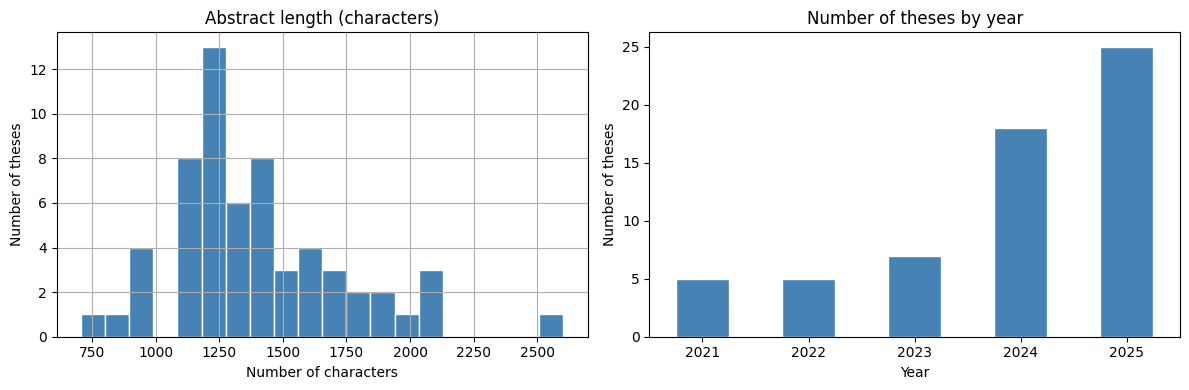

Graph saved


In [13]:
# Missing values
print("Missing values:")
missing = corpus.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "  none")


# Duplicates
dups_title = corpus.duplicated(subset="title").sum()
dups_url   = corpus.duplicated(subset="url").sum()
print(f"\nDuplicates by title: {dups_title}")
print(f"Duplicates by URL  : {dups_url}")


# Abstract lengths
corpus["abstract_len"] = corpus["abstract"].str.len()
print(f"\nAbstract length (characters):")
print(corpus["abstract_len"].describe().round(0).to_string())


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


corpus["abstract_len"].hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Abstract length (characters)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of theses")


corpus["year"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Number of theses by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of theses")
axes[1].tick_params(axis="x", rotation=0)


plt.tight_layout()
plt.savefig(BASE_PATH / "corpus_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved")

In [14]:
# Cleaning
corpus_clean = corpus.copy()


# 1. Remove duplicates
before = len(corpus_clean)
corpus_clean = corpus_clean.drop_duplicates(subset="title").reset_index(drop=True)
print(f"Duplicates removed: {before - len(corpus_clean)}")


# 2. Normalize text fields – strip whitespace, normalize spaces
for col in ["title", "abstract", "keywords", "program", "author"]:
    corpus_clean[col] = (
        corpus_clean[col]
        .fillna("")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )


# 3. Combined text for NLP (abstract + keywords)
# Keywords get a weighting bonus – we repeat them for greater influence
corpus_clean["text"] = (
    corpus_clean["abstract"] + " " + corpus_clean["keywords"]
).str.strip()


# 4. Final length check
corpus_clean["text_len"] = corpus_clean["text"].str.len()
short = corpus_clean[corpus_clean["text_len"] < 50]
if len(short) > 0:
    print(f"Warning: theses with very short text (<50 chars): {len(short)}")
    print(short[["title", "text_len"]])
else:
    print("All theses have sufficiently long text")


print(f"\nClean corpus: {len(corpus_clean)} theses")
print(f"  Average abstract length: {corpus_clean['text_len'].mean():.0f} characters")

Duplicates removed: 1
All theses have sufficiently long text

Clean corpus: 59 theses
  Average abstract length: 1483 characters


In [15]:
from stop_words import get_stop_words


# Stopwords
# Combine Czech stopwords with domain-specific words
# that have no analytical value for us
DOMAIN_STOPWORDS = {
    "práce", "bakalářská", "autor", "využití", "použití", "cíl",
    "kapitola", "část", "popis", "popisuje", "zabývá", "zaměřuje",
    "výsledek", "výsledky", "závěr", "úvod", "teoretický", "praktický",
    "analýza", "návrh", "implementace", "systém", "metoda", "přístup",
    "oblast", "rámci", "pomocí", "také", "mezi", "různých", "různé",
    "například", "tedy", "resp", "tj", "apod", "atd",
    # Slovak equivalents
    "práca", "bakalárska", "autor", "využitie", "použitie", "cieľ",
    "kapitola", "časť", "opis", "opisuje", "zaoberá", "zameriava",
    "výsledok", "výsledky", "záver", "úvod", "teoretický", "praktický",
}


stop_cs = set(get_stop_words("czech"))
stop_sk = set(get_stop_words("slovak"))
ALL_STOPWORDS = stop_cs | stop_sk | DOMAIN_STOPWORDS


print(f"Total stopwords: {len(ALL_STOPWORDS)}")
print(f"  Czech: {len(stop_cs)}, Slovak: {len(stop_sk)}, domain: {len(DOMAIN_STOPWORDS)}")

Total stopwords: 544
  Czech: 402, Slovak: 179, domain: 49


In [16]:
import re


def preprocess_text(text: str):
    """
    Tokenization + removal of stopwords and short tokens.
    We skip lemmatization. SpaCy Czech model is not available by default
    in Colab without manual installation, and for TF-IDF on short abstracts
    it provides minimal benefit compared to a simple tokenizer.
    Input: raw abstract text.
    Output: string of tokens separated by spaces (for TF-IDF and keyword extraction).
    """
    text = text.lower()
    # Keep only letters and spaces, diacritics included
    text = re.sub(r"[^a-záčďéěíňóřšťúůýžäľĺŕôâ\s]", " ", text)
    tokens = [
        tok
        for tok in text.split()
        if len(tok) > 2              # minimum length 3 characters
        and tok not in ALL_STOPWORDS # not a stopword
    ]
    return " ".join(tokens)


# Apply to the entire corpus
print("Tokenizing texts...")
corpus_clean["text_lemma"] = [
    preprocess_text(text)
    for text in tqdm(corpus_clean["text"], desc="tokenization")
]


# Sample of the first record
print("\nPreprocessing sample:")
idx = 0
print(f"Original ({len(corpus_clean.loc[idx, 'text'])} characters):")
print(f"  {corpus_clean.loc[idx, 'text'][:200]}...")
print(f"\nAfter preprocessing ({len(corpus_clean.loc[idx, 'text_lemma'].split())} tokens):")
print(f"  {corpus_clean.loc[idx, 'text_lemma'][:200]}...")

Tokenizing texts...


tokenization: 100%|██████████| 59/59 [00:00<00:00, 4085.92it/s]


Preprocessing sample:
Original (1690 characters):
  Bakalářská práce se zabývá porovnáním tří platforem, které nabízí možnost vytváření chatbotů pro vlastní využití. Význam slova chatbot je čtenářům blíže představen, ale lze ho ztotožňovat s počítačový...

After preprocessing (157 tokens):
  porovnáním tří platforem nabízí možnost vytváření chatbotů vlastní význam slova chatbot čtenářům blíže představen lze ztotožňovat počítačovým programem komunikuje lidmi zpravidla internet významné pla...


In [17]:
# Sentence embeddings
# We use a multilingual model. It supports Czech and Slovak natively.
# The model preserves the semantics of full sentences, so we use raw text
# (not lemmatized) as input. Lemmatization would destroy the context for the transformer model.
from sentence_transformers import SentenceTransformer


EMBED_MODEL = "paraphrase-multilingual-mpnet-base-v2"
print(f"Loading embedding model: {EMBED_MODEL}")
embedder = SentenceTransformer(EMBED_MODEL)


print("Generating embeddings...")
embeddings = embedder.encode(
    corpus_clean["text"].tolist(),
    show_progress_bar=True,
    batch_size=32,
)


print(f"\n Embeddings: {embeddings.shape}  (theses × dimensions)")


# Save for repeated use
np.save(BASE_PATH / "embeddings.npy", embeddings)
corpus_clean.to_csv(BASE_PATH / "corpus_clean.csv", index=False)
print(" embeddings.npy and corpus_clean.csv saved")

Loading embedding model: paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


 Embeddings: (59, 768)  (theses × dimensions)
 embeddings.npy and corpus_clean.csv saved


In [18]:
# Verify that embeddings are meaningful. Semantically similar theses
# should have higher cosine similarity.
from sklearn.metrics.pairwise import cosine_similarity


# Take the first thesis and find its 3 most similar ones
query_idx  = 0
sims       = cosine_similarity([embeddings[query_idx]], embeddings)[0]
top3_idx   = sims.argsort()[::-1][1:4]  # skip itself


print(f"Thesis: '{corpus_clean.loc[query_idx, 'title']}'")
print("\nMost similar theses (by cosine similarity of embeddings):")
for rank, i in enumerate(top3_idx, 1):
    print(f"  {rank}. [{sims[i]:.3f}] {corpus_clean.loc[i, 'title']}")


print("\nPreprocessing completed. Corpus ready for analytical views.")

Thesis: 'Porovnání platforem pro tvorbu chatbota IBM Watson Assistant, Google DialogFlow a Amazon Lex'

Most similar theses (by cosine similarity of embeddings):
  1. [0.849] Aplikace generativní umělé inteligence: chatboti v e-commerce
  2. [0.848] Implementace chatbota pro Fakultu informatiky a statistiky VŠE
  3. [0.839] Aplikace technologií umělé inteligence a rozpoznávání řeči pro vývoj AI-botů

Preprocessing completed. Corpus ready for analytical views.


In [19]:
# ALL_STOPWORDS is already defined above (after the preprocess_text cell).
# Re-importing here to make it available for the BERTopic vectorizer.
print(f"Stopwords available for BERTopic vectorizer: {len(ALL_STOPWORDS)}")

Stopwords available for BERTopic vectorizer: 544


In [20]:
# BERTopic configuration
# UMAP: reduce 768D to 5D for HDBSCAN (higher dimensions = more stable clusters),
#   then separately 2D for visualization.
# n_neighbors=10. Suitable for small corpus (around 60 theses).
# min_cluster_size=4: minimum 4 theses per cluster. Fewer would give overly
#   granular, unreliable clusters; more would blur differences.


from sklearn.feature_extraction.text import TfidfVectorizer


umap_model = UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)


hdbscan_model = HDBSCAN(
    min_cluster_size=4,
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)


# c-TF-IDF vectorizer with stopwords
vectorizer = TfidfVectorizer(
    stop_words=list(ALL_STOPWORDS),
    ngram_range=(1, 2),   # unigrams + bigrams for topic description
    min_df=2,
    max_df=0.85
)


topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True
)


# Fit: pass raw text (BERTopic tokenizes it internally for c-TF-IDF)
# Pass embeddings directly to avoid recomputing them
topics, probs = topic_model.fit_transform(
    corpus_clean["text"].tolist(),
    embeddings=embeddings
)


corpus_clean["topic"] = topics
print(f"\nNumber of topics (excluding outliers): {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Outliers (topic=-1): {sum(t == -1 for t in topics)} theses")

2026-06-10 19:40:18,254 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-10 19:40:30,795 - BERTopic - Dimensionality - Completed ✓
2026-06-10 19:40:30,796 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 19:40:30,805 - BERTopic - Cluster - Completed ✓
2026-06-10 19:40:30,808 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 19:40:30,853 - BERTopic - Representation - Completed ✓



Number of topics (excluding outliers): 3
Outliers (topic=-1): 0 theses


In [21]:
# Topics summary
topic_info = topic_model.get_topic_info()
print(topic_info[["Topic", "Count", "Name"]].to_string(index=False))

 Topic  Count                                      Name
     0     39                 0_tto_analzy_metod_metody
     1     12    1_chatbota_vytvoen_umelej_intelligence
     2      8 2_prompt_rag_velkch jazykovch_klasifikace


In [22]:
# Manual topic labeling
# BERTopic returns automatic labels from c-TF-IDF words. For readability
#   we interpret them and assign human-readable cluster names.
# This is an interpretation step. It comes from the top words of each topic.


# Show top words for each topic
for t in sorted(set(topics)):
    if t == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(t)[:8]]
    count = sum(c == t for c in topics)
    print(f"Topic {t:2d} ({count:2d} theses): {', '.join(words)}")

Topic  0 (39 theses): tto, analzy, metod, metody, jednotlivch, eten, strojov, strojov uen
Topic  1 (12 theses): chatbota, vytvoen, umelej, intelligence, rozhovor, inteligencie, umelej inteligencie, vsledkem
Topic  2 ( 8 theses): prompt, rag, velkch jazykovch, klasifikace, velkch, vlivu, gemini, rznch


In [23]:
# Topic label definitions


TOPIC_LABELS = {
     -1: "Outliers",
    0:  "Classical ML Methods & NLP",
    1:  "Chatbots & Virtual Assistants",
    2:  "LLM & RAG Applications",
}


corpus_clean["topic_label"] = corpus_clean["topic"].map(
    lambda t: TOPIC_LABELS.get(t, f"Topic {t}")
)


print("Distribution of theses by topic:")
print(corpus_clean["topic_label"].value_counts().to_string())

Distribution of theses by topic:
topic_label
Classical ML Methods & NLP       39
Chatbots & Virtual Assistants    12
LLM & RAG Applications            8


# Analytical views

## View 1: Thematic map of AIML thesis topics

In [24]:
# 2D UMAP projection for visualization
# We run 2D UMAP separately for plotting. Clustering used 5D above.
# Separation ensures that the 2D visualization does not affect the cluster structure.


umap_2d = UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)
coords_2d = umap_2d.fit_transform(embeddings)
corpus_clean["umap_x"] = coords_2d[:, 0]
corpus_clean["umap_y"] = coords_2d[:, 1]


print("2D projection completed")

2D projection completed


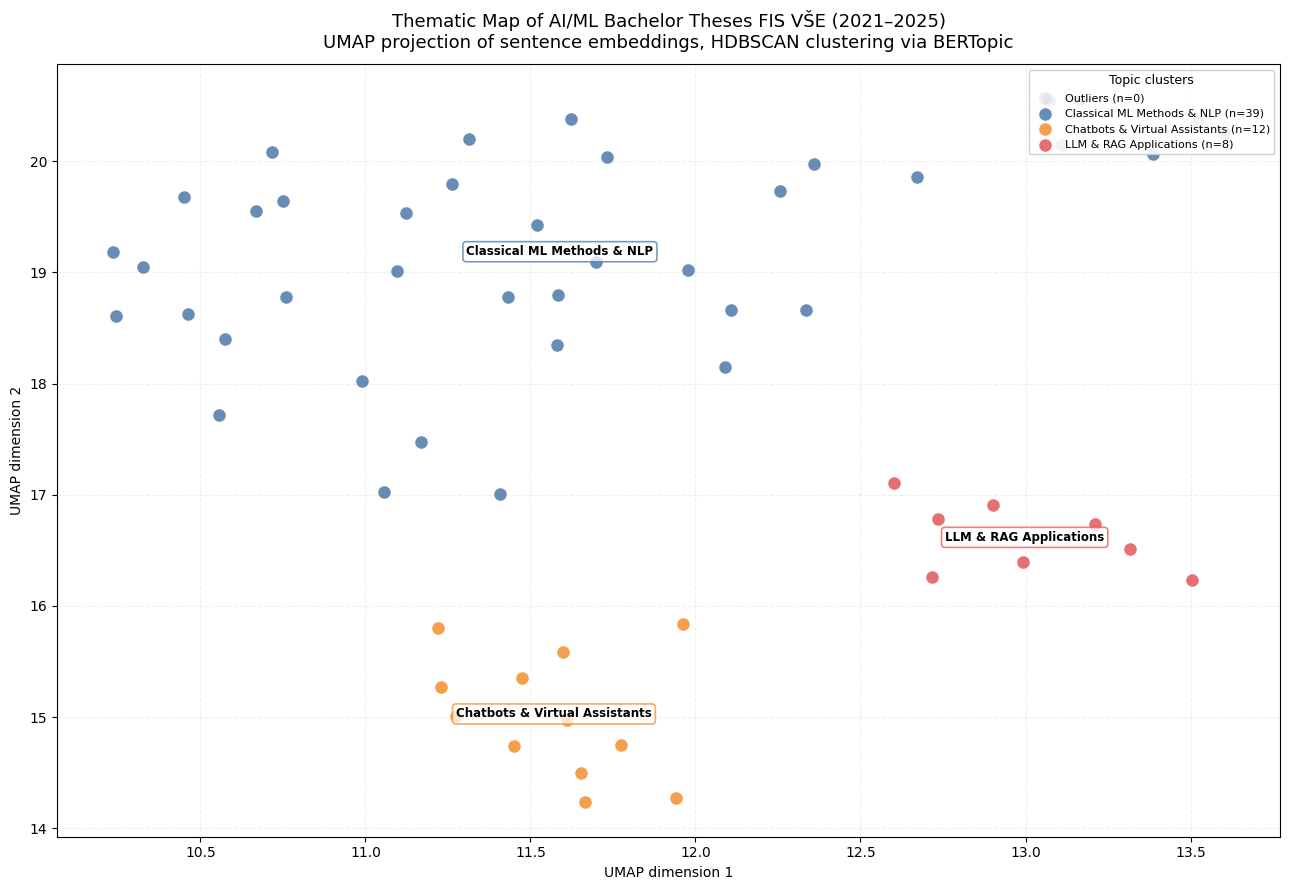

Thematic map saved


In [25]:
# Visualization: Thematic map
fig, ax = plt.subplots(figsize=(13, 9))


# Palette
palette = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
           "#59a14f", "#edc948", "#b07aa1", "#ff9da7",
           "#9c755f", "#bab0ac"]


unique_labels = sorted(
    corpus_clean["topic_label"].unique(),
    key=lambda l: (-corpus_clean[corpus_clean["topic_label"] == l].shape[0], l)
)


color_map = {"Outliers": "#cccccc"}
ci = 0
for lbl in unique_labels:
    if lbl != "Outliers":
        color_map[lbl] = palette[ci % len(palette)]
        ci += 1


# Plot. Outliers first, then colored clusters
for label in ["Outliers"] + [l for l in unique_labels if l != "Outliers"]:
    sub = corpus_clean[corpus_clean["topic_label"] == label]
    alpha = 0.35 if label == "Outliers" else 0.85
    zorder = 1 if label == "Outliers" else 2
    ax.scatter(
        sub["umap_x"], sub["umap_y"],
        c=color_map[label],
        label=f"{label} (n={len(sub)})",
        s=90, alpha=alpha, edgecolors="white", linewidths=0.5,
        zorder=zorder
    )


# Topic centroids with labels
for label in unique_labels:
    if label == "Outliers":
        continue
    sub = corpus_clean[corpus_clean["topic_label"] == label]
    cx, cy = sub["umap_x"].mean(), sub["umap_y"].mean()
    ax.annotate(
        label,
        (cx, cy),
        fontsize=8.5, fontweight="bold",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color_map[label], alpha=0.75, lw=1.2)
    )


ax.set_title("Thematic Map of AI/ML Bachelor Theses FIS VŠE (2021–2025)\n"
             "UMAP projection of sentence embeddings, HDBSCAN clustering via BERTopic",
             fontsize=13, pad=12)
ax.set_xlabel("UMAP dimension 1", fontsize=10)
ax.set_ylabel("UMAP dimension 2", fontsize=10)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9,
          title="Topic clusters", title_fontsize=9)
ax.grid(True, alpha=0.2, linestyle="--")


plt.tight_layout()
plt.savefig(BASE_PATH / "view1_thematic_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Thematic map saved")

In [26]:
# Supplementary table: most representative thesis of each cluster
# For each cluster, we select the thesis closest to the centroid (by cosine distance
#   in the embedding space).


print("Most representative thesis of each topic cluster:\n")
print(f"{'Cluster':<35} {'Year':<6} {'Thesis title':<70}")
print("-" * 115)


for label in unique_labels:
    if label == "Outliers":
        continue
    sub = corpus_clean[corpus_clean["topic_label"] == label].copy()
    idxs = sub.index.tolist()

    # Centroid in the embedding space
    centroid = embeddings[idxs].mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, embeddings[idxs])[0]
    best_local = sims.argmax()
    best_row = sub.iloc[best_local]

    title_short = best_row["title"][:68] + "..." if len(best_row["title"]) > 68 else best_row["title"]
    print(f"{label:<35} {best_row['year']:<6} {title_short:<70}")

Most representative thesis of each topic cluster:

Cluster                             Year   Thesis title                                                          
-------------------------------------------------------------------------------------------------------------------
Classical ML Methods & NLP          2025   Etické a spoločenské dopady generatívnej umelej inteligencie          
Chatbots & Virtual Assistants       2023   Implementace chatbota pro Fakultu informatiky a statistiky VŠE        
LLM & RAG Applications              2025   Pozitivní a negativní dopady velkých jazykových modelů                


## View 1: Thematic map of AIML thesis topics

### Question
What main topic groups appear in AIML bachelor theses at FIS, and what do these groups represent?

### Methodological approach
To find the main topics, I use BERTopic together with multilingual sentence embeddings. This method is a good fit for a smaller dataset because it works with the meaning of whole texts, not only with word counts.

The embeddings are reduced with UMAP to 5 dimensions and then clustered with HDBSCAN. This setup helps create groups that are stable enough to analyze, while still keeping the important semantic differences between theses.

The minimum cluster size is set to 4 theses. This avoids very small groups that would be hard to interpret and would not be useful for a strategic overview.

### Result
The model finds 3 main topic clusters and no outlier theses. This suggests that the dataset is relatively consistent and that the selected theses form a clear thematic structure rather than a random mix of unrelated topics.

The final topic groups are:
- **Classical ML Methods & NLP** : 39 theses
- **Chatbots & Virtual Assistants** : 12 theses
- **LLM & RAG Applications** : 8 theses

### Interpretation
The topic distribution shows that the AIML thesis landscape at FIS is strongly text-centric. Rather than being evenly distributed across computer vision, time-series forecasting, recommender systems, and other AIML areas, the corpus is dominated by language-related problems, text processing, and in recent years also generative AI themes.

This has two direct strategic implications. First, FIS can credibly position itself as particularly active in language-oriented AIML work, which aligns well with current industry demand. Second, the relatively low thematic diversity may indicate a gap: if the faculty wants a broader AIML profile, it may need to actively encourage theses in underrepresented areas such as computer vision, reinforcement learning, or multimodal systems.

## View 2: Original research vs. tool deployment

In [27]:
# Signal dictionaries
# Signals for ORIGINALITY: thesis proposes its own model, conducts experiments,
#   trains on its own data, compares its own architectures.
ORIGINAL_SIGNALS = [
    # Czech
    "navrhuje", "navrhnout", "navrhli", "nový model", "vlastní model",
    "trénování", "trénovali", "natrenován", "natrénovány",
    "vlastní dataset", "vlastní data", "sběr dat",
    "anotaci", "anotace", "anotovat",
    "experiment", "experimentování", "experimentální",
    "architektura", "vlastní architektura", "modifikace architektury",
    "optimalizace hyperparametrů", "ladění hyperparametrů",
    "porovnání modelů", "srovnání modelů", "porovnáme modely",
    "fine-tuning", "fine tuning", "doladit", "doladění",
    # Slovak
    "navrhuje", "návrh modelu", "vlastný model",
    "trénovanie", "trénoval", "natrénovany",
    "vlastné dáta", "zber dát",
    "experiment", "experimentovanie",
]


# Signals for TOOL DEPLOYMENT: thesis uses existing frameworks, APIs,
#   pre-trained models. Focus on integration, configuration, comparing tool performance.
TOOL_SIGNALS = [
    # Czech
    "použití", "využití", "nasazení", "integrace",
    "aplikování", "aplikace", "existující", "hotový", "předtrénovaný",
    "předtrénovaného", "předtrénované", "hotové nástroje",
    "framework", "knihovna", "platforma", "api",
    "openai", "gpt", "chatgpt", "azure", "google cloud", "aws",
    "scikit-learn", "sklearn", "tensorflow", "keras", "pytorch",
    "xgboost", "lightgbm", "hugging face", "transformers",
    "bert", "word2vec", "fasttext",
    "porovnání nástrojů", "srovnání nástrojů",
    "nasazení modelu", "deployment",
    # Slovak
    "použitie", "využitie", "nasadenie", "integrácia",
    "existujúci", "hotový", "predtrénovaný",
]


def classify_originality(abstract: str):
    """
    Return "Original research", "Tool deployment" or "Combination"
    based on the number of signals in the abstract text.
    Threshold: ≥2 signals from one category.
    """
    text = abstract.lower()
    score_orig = sum(1 for s in ORIGINAL_SIGNALS if s in text)
    score_tool = sum(1 for s in TOOL_SIGNALS if s in text)

    # If equal or both above threshold -> Combination
    if score_orig >= 2 and score_tool >= 2:
        return "Combination"
    if score_orig > score_tool and score_orig >= 2:
        return "Original research"
    if score_tool > score_orig and score_tool >= 2:
        return "Tool deployment"
    # Weak signals. Assign based on dominance
    if score_orig > score_tool:
        return "Original research"
    if score_tool > score_orig:
        return "Tool deployment"
    return "Combination"  # True uncertainty


corpus_clean["originality"] = corpus_clean["abstract"].apply(classify_originality)


print("Overall distribution:")
print(corpus_clean["originality"].value_counts().to_string())

Overall distribution:
originality
Tool deployment      42
Combination          15
Original research     2


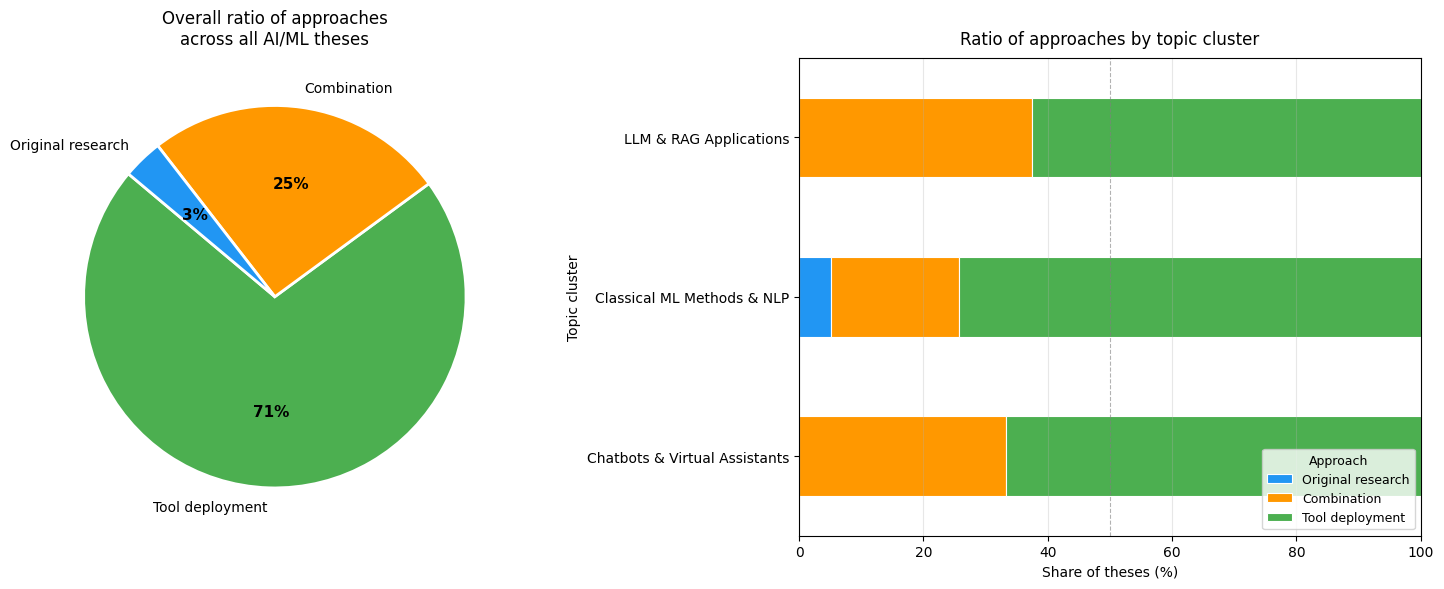

In [28]:
# Visualization: overall ratio + breakdown by cluster
ORIG_COLORS = {
    "Original research": "#2196F3",
    "Combination":       "#FF9800",
    "Tool deployment":   "#4CAF50",
}


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


# Left graph: overall pie chart
counts = corpus_clean["originality"].value_counts()
colors_pie = [ORIG_COLORS[k] for k in counts.index]
wedges, texts, autotexts = axes[0].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=colors_pie,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
axes[0].set_title("Overall ratio of approaches\nacross all AI/ML theses",
                  fontsize=12, pad=10)


# Right graph: stacked bar by cluster
# Only clusters with ≥3 theses (outliers excluded)
cluster_filter = (
    corpus_clean[corpus_clean["topic_label"] != "Outliers"]
    .groupby("topic_label").filter(lambda x: len(x) >= 3)
)


ct = pd.crosstab(
    cluster_filter["topic_label"],
    cluster_filter["originality"],
    normalize="index"
) * 100  # percentages


# Sort columns consistently
cat_order = ["Original research", "Combination", "Tool deployment"]
ct = ct.reindex(columns=[c for c in cat_order if c in ct.columns])


ct.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=[ORIG_COLORS[c] for c in ct.columns],
    edgecolor="white",
    linewidth=0.8
)


axes[1].set_xlabel("Share of theses (%)", fontsize=10)
axes[1].set_ylabel("Topic cluster", fontsize=10)
axes[1].set_title("Ratio of approaches by topic cluster",
                  fontsize=12, pad=10)
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].legend(
    title="Approach", loc="lower right",
    fontsize=9, title_fontsize=9
)
axes[1].grid(axis="x", alpha=0.3)


plt.tight_layout()
plt.savefig(BASE_PATH / "view2_originality.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Sample theses from each category
print("Sample theses by category:\n")
for cat in ["Original research", "Combination", "Tool deployment"]:
    sub = corpus_clean[corpus_clean["originality"] == cat]
    sample = sub.sample(min(2, len(sub)), random_state=SEED)
    print(f"── {cat} ({len(sub)} theses) ──")
    for _, row in sample.iterrows():
        title = row["title"][:80] + "..." if len(row["title"]) > 80 else row["title"]
        print(f"  [{row['year']}] {title}")
    print()

Sample theses by category:

── Original research (2 theses) ──
  [2024] Vyhodnocení agenta SARSA v testu algoritmického IQ
  [2025] Rozpoznávanie škodlivého obsahu na internete pomocou strojového učenia

── Combination (15 theses) ──
  [2025] Analýza trhu cloudových služeb strojového učení a umělé inteligence
  [2023] Variační autoenkodér a úlohy pozorování v latentním prostoru

── Tool deployment (42 theses) ──
  [2025] Predikce výsledků ve Formuli 1
  [2024] Interpretace konjunkce ve velkých jazykových modelech



## View 2: Original research vs. tool deployment

### Question
Do students mainly create their own AIML solutions, or do they mostly apply existing tools and platforms?

### Methodological approach
To answer this question, I classify each thesis into one of three categories: **Original research**, **Combination**, or **Tool deployment**. The classification is based on signals in the abstract, such as whether the thesis proposes its own model, trains or fine-tunes a model, works with its own dataset, or mainly implements and compares existing tools.

This is not a perfect measure of originality, but it provides a useful overview of how ambitious and technically independent the theses are. It is especially helpful for comparing the overall balance of the portfolio and differences across topic groups.

### Result
The overall picture is strongly tilted toward the use of existing tools. Out of 59 theses, **42** are classified as **Tool deployment** (71%), **15** as **Combination** (25%), and only **2** as **Original research** (3%).

The cluster-level breakdown shows that this pattern is visible across the topic landscape, although some groups contain slightly more mixed projects than others.

### Interpretation
The main takeaway is that most AIML theses at FIS are practical application projects rather than fully original research projects. Students often work with existing platforms, models, or frameworks and focus on implementation, comparison, or use in a specific context.

This is not necessarily a weakness, because applied work can still be valuable for teaching and external cooperation. However, if the faculty wants to strengthen its research profile, it may need to motivate more theses that include model development, experimentation, or more original methodological contributions.

## View 3: Temporal evolution of the thesis landscape

In [30]:
# Technology categories
# We split technologies into three generations for trend analysis.
# Each generation represents a historical wave of AI/ML development.


TECH_GROUPS = {
    "Traditional ML": [
        "random forest", "náhodný les", "rozhodovací strom", "decision tree",
        "svm", "support vector", "podpůrný vektor",
        "logistická regrese", "logistic regression",
        "xgboost", "lightgbm", "gradient boosting", "gradientní boosting",
        "naive bayes", "naivní bayes", "k-nearest", "knn",
        "scikit", "sklearn",
    ],
    "Deep Learning (CNN/RNN)": [
        "neuronová síť", "neural network", "konvoluční", "cnn",
        "rekurentní", "rnn", "lstm", "gru",
        "tensorflow", "keras", "pytorch",
        "hluboké učení", "deep learning",
        "počítačové vidění", "computer vision",
        "rozpoznávání obrazu", "image recognition", "object detection",
    ],
    "Transformers & LLM": [
        "transformér", "transformer", "bert", "gpt", "llm",
        "jazykový model", "language model", "velký jazykový",
        "generativní", "generative", "chatgpt", "openai",
        "hugging face", "fine-tuning", "fine tuning",
        "rag", "retrieval augmented", "embeddingy", "embeddings",
        "sentence transformer",
    ],
}


def detect_tech_groups(abstract: str):
    """Return a list of technology groups present in the abstract."""
    text = abstract.lower()
    found = []
    for group, keywords in TECH_GROUPS.items():
        if any(kw in text for kw in keywords):
            found.append(group)
    return found if found else ["Uncategorized"]


# Each thesis can belong to multiple groups. Expand to long-form table
tech_rows = []
for _, row in corpus_clean.iterrows():
    groups = detect_tech_groups(row["abstract"])
    for g in groups:
        tech_rows.append({"year": row["year"], "tech_group": g})


tech_df = pd.DataFrame(tech_rows)
print("Technology groups (overall):")
print(tech_df["tech_group"].value_counts().to_string())

Technology groups (overall):
tech_group
Transformers & LLM         29
Uncategorized              24
Traditional ML              7
Deep Learning (CNN/RNN)     4


In [31]:
# Temporal tables
# 1. Number of theses by year and technology group
tech_pivot = (
    tech_df[tech_df["tech_group"] != "Uncategorized"]
    .groupby(["year", "tech_group"])
    .size()
    .unstack(fill_value=0)
)


# 2. Number of theses by year and topic cluster
topic_pivot = (
    corpus_clean[corpus_clean["topic_label"] != "Outliers"]
    .groupby(["year", "topic_label"])
    .size()
    .unstack(fill_value=0)
)


print("Technology groups by year:")
print(tech_pivot.to_string())
print("\nTopic clusters by year:")
print(topic_pivot.to_string())

Technology groups by year:
tech_group  Deep Learning (CNN/RNN)  Traditional ML  Transformers & LLM
year                                                                   
2021                              0               1                   0
2022                              0               1                   0
2023                              1               1                   3
2024                              3               1                  10
2025                              0               3                  16

Topic clusters by year:
topic_label  Chatbots & Virtual Assistants  Classical ML Methods & NLP  LLM & RAG Applications
year                                                                                          
2021                                     3                           2                       0
2022                                     1                           3                       1
2023                                     3                      

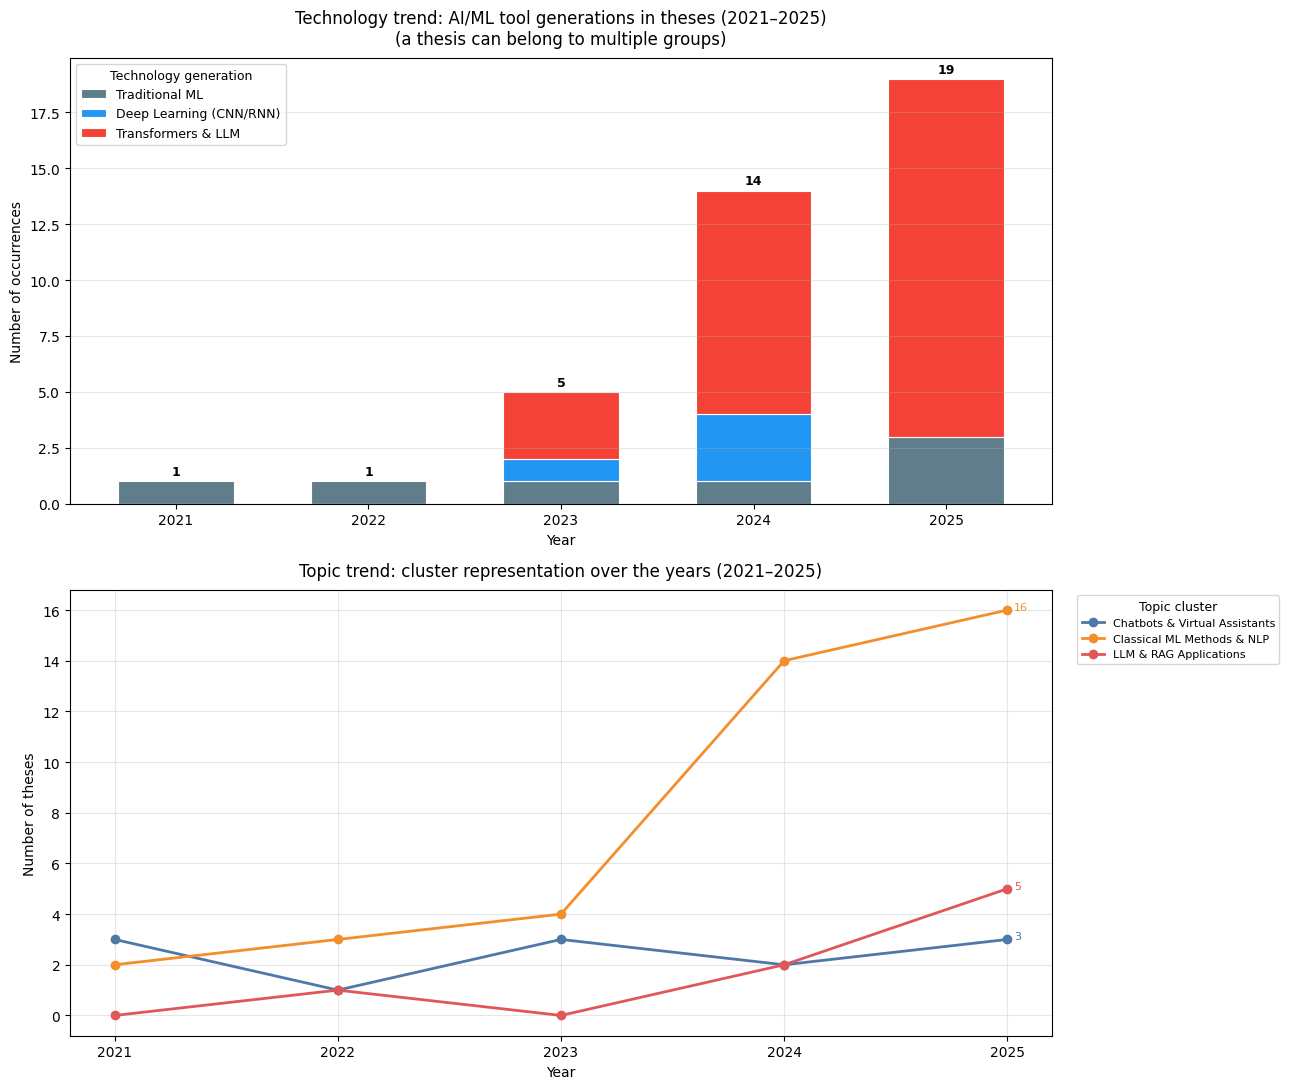

In [32]:
# Temporal evolution visualization
fig, axes = plt.subplots(2, 1, figsize=(13, 11))


# Top: technology trend (stacked area)
TECH_COLORS = {
    "Traditional ML":         "#607D8B",
    "Deep Learning (CNN/RNN)": "#2196F3",
    "Transformers & LLM":     "#F44336",
    "Uncategorized":          "#E0E0E0",
}


tech_cols = [c for c in ["Traditional ML", "Deep Learning (CNN/RNN)", "Transformers & LLM"]
             if c in tech_pivot.columns]
tech_plot = tech_pivot[tech_cols]


tech_plot.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[TECH_COLORS[c] for c in tech_cols],
    edgecolor="white", linewidth=0.8, width=0.6
)


axes[0].set_title("Technology trend: AI/ML tool generations in theses (2021–2025)\n"
                  "(a thesis can belong to multiple groups)",
                  fontsize=12, pad=10)
axes[0].set_xlabel("Year", fontsize=10)
axes[0].set_ylabel("Number of occurrences", fontsize=10)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Technology generation", fontsize=9, title_fontsize=9)
axes[0].grid(axis="y", alpha=0.3)


# Add absolute numbers above bars
totals = tech_plot.sum(axis=1)
for i, (yr, total) in enumerate(totals.items()):
    axes[0].text(i, total + 0.15, str(int(total)),
                 ha="center", va="bottom", fontsize=9, fontweight="bold")


# Bottom: topic trend (line chart)
# For topics, we prefer line chart. It shows trends more clearly than stacked bar.
palette_line = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
                "#59a14f", "#edc948", "#b07aa1", "#ff9da7"]


for i, col in enumerate(topic_pivot.columns):
    axes[1].plot(
        topic_pivot.index, topic_pivot[col],
        marker="o", linewidth=2, markersize=6,
        color=palette_line[i % len(palette_line)],
        label=col
    )
    # Annotate the last value
    last_y = topic_pivot[col].iloc[-1]
    last_x = topic_pivot.index[-1]
    axes[1].annotate(
        f"{last_y:.0f}",
        (last_x, last_y),
        xytext=(5, 0), textcoords="offset points",
        fontsize=8, color=palette_line[i % len(palette_line)]
    )


axes[1].set_title("Topic trend: cluster representation over the years (2021–2025)",
                  fontsize=12, pad=10)
axes[1].set_xlabel("Year", fontsize=10)
axes[1].set_ylabel("Number of theses", fontsize=10)
axes[1].set_xticks(topic_pivot.index)
axes[1].legend(title="Topic cluster", fontsize=8, title_fontsize=9,
               bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.savefig(BASE_PATH / "view3_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

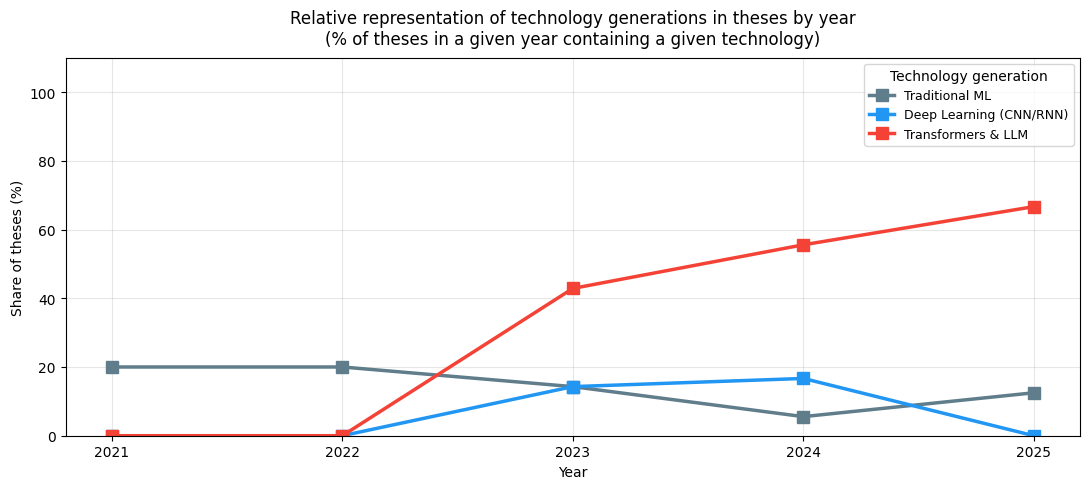

In [33]:
# Supplement: relative technology share (normalized by year)
# Absolute numbers can be skewed by varying thesis counts per year.
# We normalize by the total number of theses in each year.


# Total number of theses by year
yearly_total = corpus_clean.groupby("year").size()


# Normalized technology table
tech_norm = tech_plot.div(yearly_total, axis=0).fillna(0) * 100


fig, ax = plt.subplots(figsize=(11, 5))


for i, col in enumerate(tech_norm.columns):
    ax.plot(
        tech_norm.index, tech_norm[col],
        marker="s", linewidth=2.5, markersize=8,
        color=TECH_COLORS[col],
        label=col
    )


ax.set_title("Relative representation of technology generations in theses by year\n"
             "(% of theses in a given year containing a given technology)",
             fontsize=12, pad=10)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Share of theses (%)", fontsize=10)
ax.set_xticks(tech_norm.index)
ax.legend(title="Technology generation", fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 110)


plt.tight_layout()
plt.savefig(BASE_PATH / "view3_tech_relative.png", dpi=150, bbox_inches="tight")
plt.show()

## View 3: Temporal evolution of the thesis landscape

### Question
How has the AIML thesis landscape changed over time between 2021 and 2025?

### Methodological approach
This view combines two trend analyses. First, I track the occurrence of broader technology generations in thesis abstracts, especially **Traditional ML**, **Deep Learning / CNN-RNN**, and **Transformers / LLM**. Second, I compare how the main topic clusters are distributed across individual years.

This approach makes it possible to see not only whether the number of theses changes over time, but also whether the dominant methods and themes are shifting. That is more useful than looking at total counts alone.

### Result
The clearest trend is the rise of **Transformers / LLM** topics in the most recent years. In the full dataset, these technologies appear much more often than older AIML generations, with **29** recorded occurrences, compared with **7** for Traditional ML and **4** for Deep Learning / CNN-RNN.

The yearly breakdown shows that transformer-related topics become much more visible in **2024** and especially **2025**. At the same time, the topic-cluster view suggests that the thesis portfolio remains strongly centered on text-oriented work throughout the whole period.

### Interpretation
The thesis landscape does not look static. It reacts to broader developments in AI, especially the rapid rise of generative AI and large language models.

For FIS, this suggests that the faculty is responsive to current technological trends. At the same time, the strong concentration in recent transformer-related work may also mean that some older or alternative AIML approaches are losing space in the student portfolio.

## View 4: Application domains of AIML theses

In [34]:
DOMAIN_KEYWORDS = {
    "Finance & Banking": [
        "akcie", "burza", "cena akcie", "finanční trh", "kryptoměna", "bitcoin",
        "banka", "bankovnictví", "úvěr", "úvěrové riziko", "platební karta",
        "podvod", "fraud", "pojištění", "investice", "portfolio",
        "obchodování", "trading", "výnos", "riziko",
        "stock", "financial", "credit", "loan",
    ],
    "E-commerce & Marketing": [
        "e-commerce", "e-shop", "zákazník", "zákaznický", "churn",
        "doporučovací", "doporučení produktu", "nákupní", "nákup",
        "marketing", "reklama", "kampaň", "konverze",
        "recenze", "hodnocení produktu", "sentiment zákazník",
        "cena produktu", "predikce poptávky",
        "customer", "retail", "recommendation",
    ],
    "Healthcare & Medicine": [
        "zdravotnictví", "medicína", "lékařský", "klinický",
        "diagnóza", "diagnózy", "diagnostika", "nemocnice",
        "pacient", "choroba", "onemocnění", "léčba",
        "rentgen", "mri", "ct snímek", "medicínský obraz",
        "medical", "health", "clinical", "patient", "disease",
    ],
    "Industry & IoT": [
        "průmysl", "výroba", "továrna", "stroj", "senzor",
        "iot", "internet věcí", "prediktivní údržba",
        "detekce závady", "detekce poruchy", "anomálie výrobní",
        "energetika", "spotřeba energie", "smart grid",
        "manufacturing", "industrial", "maintenance",
    ],
    "Cybersecurity": [
        "kybernetická bezpečnost", "bezpečnost sítě", "útok", "malware",
        "phishing", "spam", "detekce útoků", "intrusion",
        "síťový provoz", "anomálie v síti", "cybersecurity",
        "network security", "threat",
    ],
    "Media & Social Networks": [
        "sociální síť", "twitter", "facebook", "instagram", "reddit",
        "fake news", "dezinformace", "média", "novinový", "článek",
        "komentář", "příspěvek", "sentiment médií",
        "social media", "news", "misinformation",
    ],
    "Education & HR": [
        "vzdělávání", "student", "výuka", "e-learning",
        "personalizované učení", "adaptivní",
        "hr", "lidské zdroje", "nábor", "životopis", "zaměstnanec",
        "výkon zaměstnance", "odměňování",
        "education", "learning", "recruitment",
    ],
    "Transport & Logistics": [
        "doprava", "logistika", "trasa", "optimalizace trasy",
        "autonomní vozidlo", "řízení", "dopravní",
        "zásilka", "dodávka", "sklady", "supply chain",
        "transport", "routing", "delivery",
    ],
}


def detect_domains(abstract: str):
    text = abstract.lower()
    found = [domain for domain, kws in DOMAIN_KEYWORDS.items() if any(k in text for k in kws)]
    return found if found else ["Other / Uncategorized"]

In [35]:
domain_rows = []
for _, row in corpus_clean.iterrows():
    for d in detect_domains(row["abstract"]):
        domain_rows.append({
            "year": row["year"],
            "domain": d,
            "title": row.get("title", "")
        })


domain_df = pd.DataFrame(domain_rows)
corpus_clean["primary_domain"] = corpus_clean["abstract"].apply(lambda a: detect_domains(a)[0])


print("Application domains (overall, long-form):")
print(domain_df["domain"].value_counts().to_string())

Application domains (overall, long-form):
domain
Education & HR             35
Industry & IoT             29
Other / Uncategorized      11
Healthcare & Medicine       5
Finance & Banking           4
E-commerce & Marketing      3
Transport & Logistics       1
Media & Social Networks     1


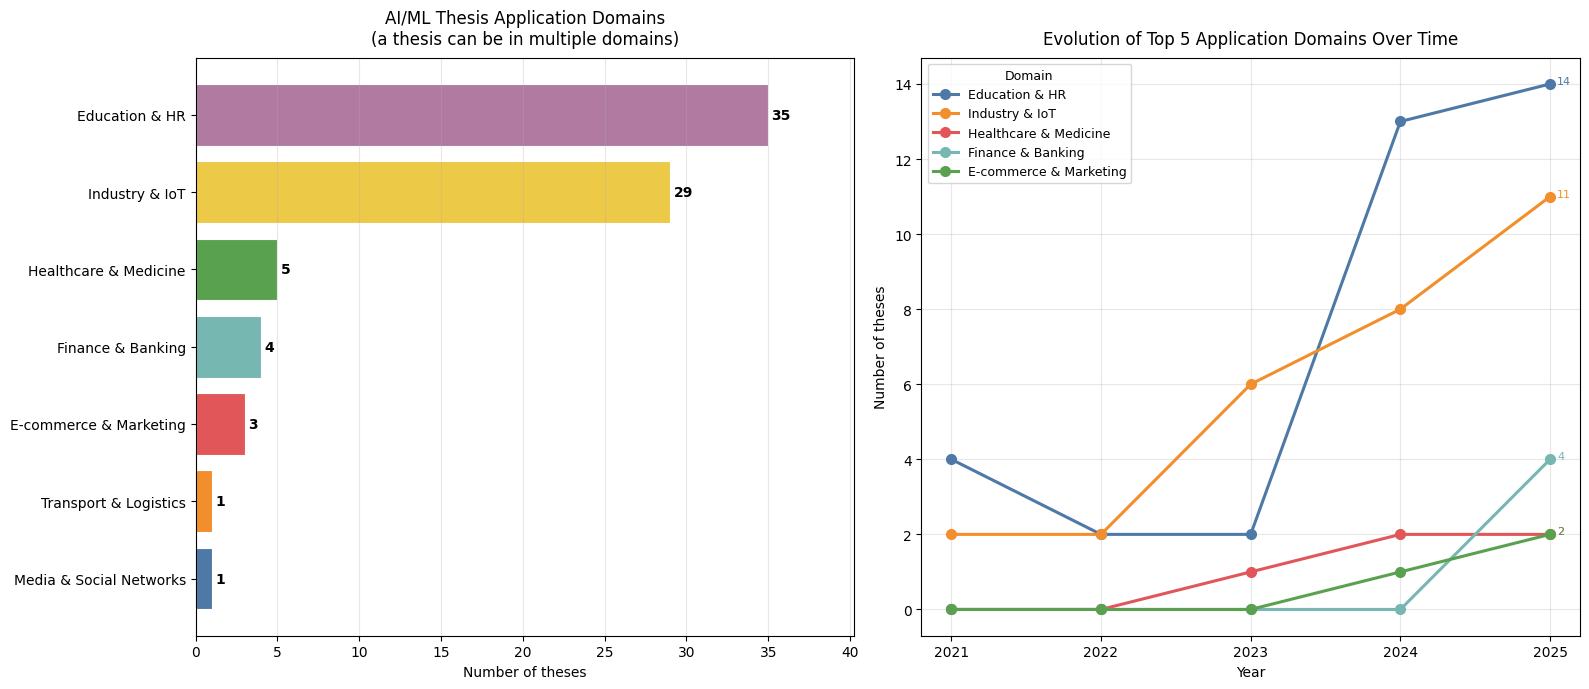

In [36]:
DOMAIN_COLORS = [
    "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
    "#59a14f", "#edc948", "#b07aa1", "#ff9da7", "#bab0ac"
]


fig, axes = plt.subplots(1, 2, figsize=(16, 7))


domain_counts = (
    domain_df[domain_df["domain"] != "Other / Uncategorized"]["domain"].value_counts()
)


bars = axes[0].barh(
    domain_counts.index[::-1],
    domain_counts.values[::-1],
    color=DOMAIN_COLORS[:len(domain_counts)],
    edgecolor="white",
    linewidth=0.8
)


for bar, val in zip(bars, domain_counts.values[::-1]):
    axes[0].text(
        val + 0.2, bar.get_y() + bar.get_height() / 2,
        str(val), va="center", ha="left", fontsize=10, fontweight="bold"
    )


axes[0].set_title("AI/ML Thesis Application Domains\n(a thesis can be in multiple domains)", fontsize=12, pad=10)
axes[0].set_xlabel("Number of theses", fontsize=10)
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_xlim(0, domain_counts.max() * 1.15)


top5_domains = domain_counts.head(5).index.tolist()


domain_time = (
    domain_df[domain_df["domain"].isin(top5_domains)]
    .groupby(["year", "domain"])
    .size()
    .unstack(fill_value=0)
)


palette_line = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]


for i, col in enumerate(top5_domains):
    if col not in domain_time.columns:
        continue
    axes[1].plot(
        domain_time.index, domain_time[col],
        marker="o", linewidth=2.2, markersize=7,
        color=palette_line[i],
        label=col
    )
    last_val = domain_time[col].iloc[-1]
    axes[1].annotate(
        f"{last_val:.0f}",
        (domain_time.index[-1], last_val),
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8,
        color=palette_line[i]
    )


axes[1].set_title("Evolution of Top 5 Application Domains Over Time", fontsize=12, pad=10)
axes[1].set_xlabel("Year", fontsize=10)
axes[1].set_ylabel("Number of theses", fontsize=10)
axes[1].set_xticks(domain_time.index)
axes[1].legend(title="Domain", fontsize=9, title_fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))


plt.tight_layout()
plt.savefig(BASE_PATH / "view4_domains.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
years_sorted = sorted(corpus_clean["year"].unique())
last_year = years_sorted[-1] if len(years_sorted) >= 1 else None
prev_year = years_sorted[-2] if len(years_sorted) >= 2 else None


summary_rows = []
for domain, count in domain_counts.items():
    last_n = len(domain_df[(domain_df["domain"] == domain) & (domain_df["year"] == last_year)])
    prev_n = len(domain_df[(domain_df["domain"] == domain) & (domain_df["year"] == prev_year)]) if prev_year else 0
    delta = last_n - prev_n
    trend = "increasing" if delta > 0 else ("decreasing" if delta < 0 else "stable")
    summary_rows.append({
        "Domain": domain,
        "Total theses": int(count),
        f"Theses {last_year}": int(last_n),
        "Trend": trend,
    })


domain_summary = pd.DataFrame(summary_rows).sort_values("Total theses", ascending=False)
print("Overview of application domains – input for industrial partnership strategy:\n")
print(domain_summary.to_string(index=False))

Overview of application domains – input for industrial partnership strategy:

                 Domain  Total theses  Theses 2025      Trend
         Education & HR            35           14 increasing
         Industry & IoT            29           11 increasing
  Healthcare & Medicine             5            2     stable
      Finance & Banking             4            4 increasing
 E-commerce & Marketing             3            2 increasing
  Transport & Logistics             1            1 increasing
Media & Social Networks             1            1 increasing


## View 4: Application domains of AIML theses

### Question
In which application areas do students most often apply AIML methods?

### Methodological approach
This view focuses on the practical context of each thesis rather than on the algorithm itself. Each thesis is assigned to an application domain based on its title, abstract, and keywords, so the analysis captures where AIML is being used, not only how it is implemented.

This distinction is important because two theses may use similar methods but solve very different problems. From a strategic point of view, application domains are useful for understanding links to teaching priorities, labor-market relevance, and possible external partnerships.

### Result
The domain map shows that AIML theses are not spread evenly across all business and technical areas. Instead, they are concentrated in a smaller number of recurring application contexts, especially those linked to text processing, digital communication, and data-driven decision support.

This pattern is consistent with the earlier views: the strongest parts of the portfolio are not only methodologically text-oriented, but also often connected to language-based use cases in practice.

### Interpretation
The application-domain perspective confirms that the thesis landscape has a relatively clear practical focus. Students do not choose AIML topics randomly. Many projects are concentrated in a few domains where the methods are accessible, relevant, and easy to connect to real organizational needs.

For FIS, this can be useful in two ways. The faculty can present these domains as areas of existing strength, but it can also identify which application areas remain underrepresented and might deserve more active support in future thesis topics.

## View 5: Technology groups and tools used in student projects

In [38]:
TOOLS = {
    "scikit-learn": [r"scikit[- ]?learn", r"\bsklearn\b"],
    "TensorFlow":   [r"tensorflow"],
    "Keras":        [r"\bkeras\b"],
    "PyTorch":      [r"pytorch", r"torch\b"],
    "Hugging Face": [r"hugging face", r"huggingface"],
    "XGBoost":      [r"\bxgboost\b"],
    "LightGBM":     [r"\blightgbm\b"],
    "spaCy":        [r"\bspacy\b"],
    "NLTK":         [r"\bnltk\b"],
    "OpenCV":       [r"\bopencv\b"],
    "BERT":         [r"\bbert\b"],
    "GPT":          [r"\bgpt[- ]?\d?\b", r"\bchatgpt\b"],
    "LLaMA":        [r"\bllama\b"],
    "Word2Vec":     [r"word2vec"],
    "FastText":     [r"fasttext"],
    "LSTM":         [r"\blstm\b"],
    "CNN":          [r"\bcnn\b", r"konvoluční síť", r"konvoluční neural"],
    "Random Forest":[r"random forest", r"náhodný les"],
    "SVM":          [r"\bsvm\b", r"support vector", r"podpůrný vektor"],
    "Transformer":  [r"\btransformér\b", r"\btransformer\b"],
    "OpenAI API":   [r"openai api", r"openai\.com"],
    "LangChain":    [r"\blangchain\b"],
    "RAG":          [r"\brag\b", r"retrieval.augmented"],
}

def detect_tools(abstract: str, keywords: str = "") -> list:
    """Detect tool/model names in abstract and keywords combined."""
    text = (abstract + " " + keywords).lower()
    return [tool for tool, patterns in TOOLS.items() if any(re.search(p, text) for p in patterns)]

In [39]:
tool_rows = []
for _, row in corpus_clean.iterrows():
    # Search in both abstract and keywords for better coverage
    for t in detect_tools(row["abstract"], row.get("keywords", "")):
        tool_rows.append({"year": row["year"], "tool": t})

tool_df = pd.DataFrame(tool_rows)
tool_counts = tool_df["tool"].value_counts()

print("Tools and models (overall):")
print(tool_counts.to_string())

Tools and models (overall):
tool
GPT              16
LLaMA             3
Random Forest     2
Transformer       2
RAG               2
XGBoost           1
BERT              1


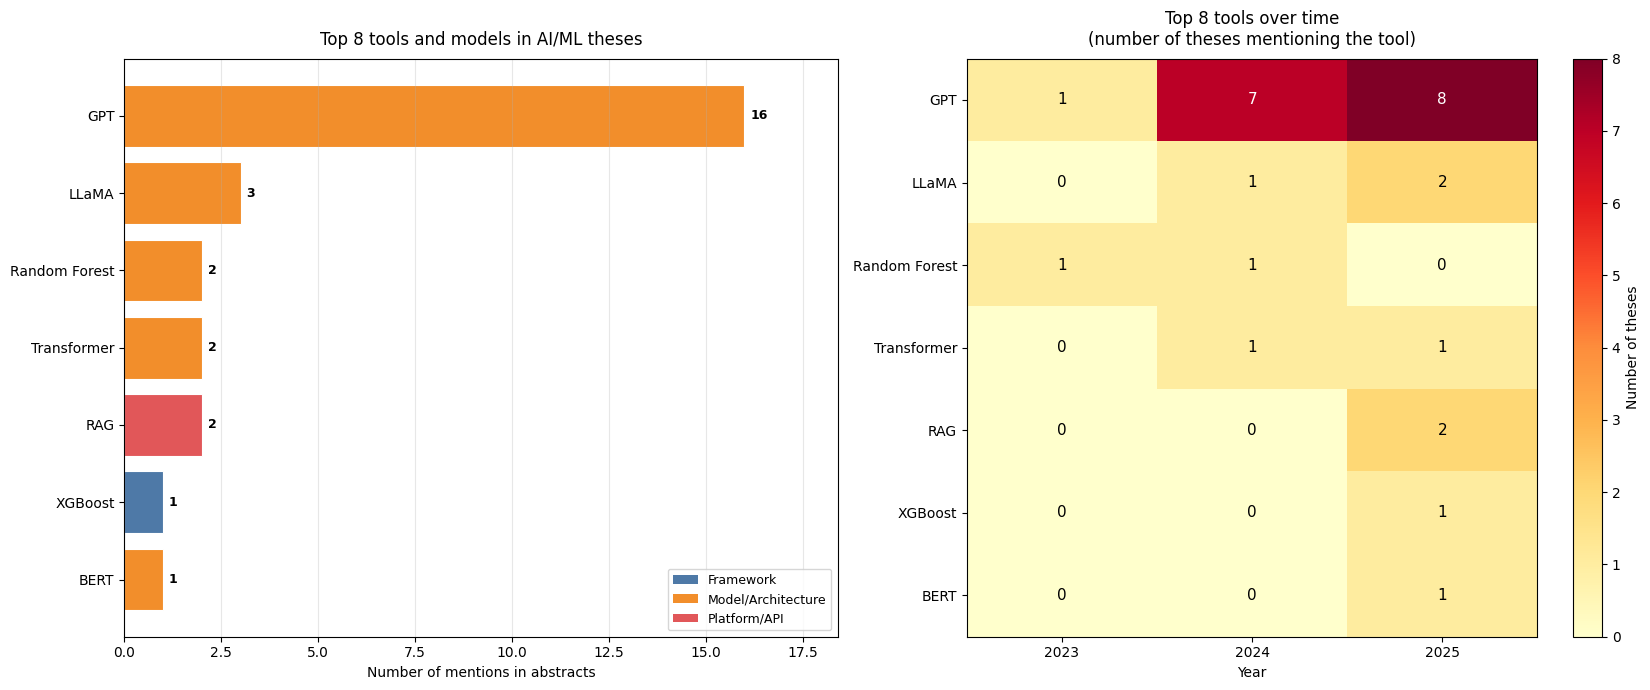

In [40]:
from matplotlib.patches import Patch


fig, axes = plt.subplots(1, 2, figsize=(17, 7))


top_n = 8
top_tools = tool_counts.head(top_n)


TOOL_CATEGORY = {
    "scikit-learn": "Framework", "TensorFlow": "Framework", "Keras": "Framework",
    "PyTorch": "Framework", "Hugging Face": "Framework",
    "XGBoost": "Framework", "LightGBM": "Framework",
    "spaCy": "Framework", "NLTK": "Framework", "OpenCV": "Framework",
    "BERT": "Model/Architecture", "GPT": "Model/Architecture",
    "LLaMA": "Model/Architecture", "Word2Vec": "Model/Architecture",
    "FastText": "Model/Architecture", "LSTM": "Model/Architecture",
    "CNN": "Model/Architecture", "Random Forest": "Model/Architecture",
    "SVM": "Model/Architecture", "Transformer": "Model/Architecture",
    "OpenAI API": "Platform/API", "LangChain": "Platform/API",
    "RAG": "Platform/API",
}


CAT_COLORS = {
    "Framework": "#4e79a7",
    "Model/Architecture": "#f28e2b",
    "Platform/API": "#e15759",
}


bar_colors = [CAT_COLORS.get(TOOL_CATEGORY.get(t, "Framework"), "#bab0ac") for t in top_tools.index]


bars = axes[0].barh(
    top_tools.index[::-1],
    top_tools.values[::-1],
    color=bar_colors[::-1],
    edgecolor="white",
    linewidth=0.8
)


for bar, val in zip(bars, top_tools.values[::-1]):
    axes[0].text(
        val + 0.15, bar.get_y() + bar.get_height() / 2,
        str(val), va="center", ha="left", fontsize=9, fontweight="bold"
    )


legend_elements = [Patch(facecolor=v, label=k) for k, v in CAT_COLORS.items()]
axes[0].legend(handles=legend_elements, fontsize=9, loc="lower right")


axes[0].set_title(f"Top {top_n} tools and models in AI/ML theses", fontsize=12, pad=10)
axes[0].set_xlabel("Number of mentions in abstracts", fontsize=10)
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_xlim(0, top_tools.max() * 1.15)


top8_tools = tool_counts.head(8).index.tolist()


tool_time = (
    tool_df[tool_df["tool"].isin(top8_tools)]
    .groupby(["year", "tool"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top8_tools)
)


im = axes[1].imshow(
    tool_time.T.values,
    aspect="auto",
    cmap="YlOrRd",
    vmin=0
)


axes[1].set_xticks(range(len(tool_time.index)))
axes[1].set_xticklabels(tool_time.index, fontsize=10)
axes[1].set_yticks(range(len(top8_tools)))
axes[1].set_yticklabels(top8_tools, fontsize=10)


for yi, tool in enumerate(top8_tools):
    for xi, yr in enumerate(tool_time.index):
        val = tool_time.loc[yr, tool] if tool in tool_time.columns else 0
        axes[1].text(
            xi, yi, str(int(val)),
            ha="center", va="center", fontsize=11,
            color="white" if val >= tool_time.values.max() * 0.6 else "black"
        )


plt.colorbar(im, ax=axes[1], label="Number of theses")
axes[1].set_title("Top 8 tools over time\n(number of theses mentioning the tool)", fontsize=12, pad=10)
axes[1].set_xlabel("Year", fontsize=10)


plt.tight_layout()
plt.savefig(BASE_PATH / "view5_tech_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
last_yr = sorted(corpus_clean["year"].unique())[-1]
total_n = len(corpus_clean)
last_n = len(corpus_clean[corpus_clean["year"] == last_yr])


curriculum_rows = []
for tool, total_count in tool_counts.items():
    count_last = len(tool_df[(tool_df["tool"] == tool) & (tool_df["year"] == last_yr)])
    share_total = total_count / total_n * 100
    share_last = count_last / last_n * 100 if last_n > 0 else 0
    momentum = share_last - share_total
    curriculum_rows.append({
        "Tool": tool,
        "Category": TOOL_CATEGORY.get(tool, "?"),
        "Total theses": int(total_count),
        "Share overall (%)": round(share_total, 1),
        f"Share {last_yr} (%)": round(share_last, 1),
        "Momentum": round(momentum, 1),
        "Curriculum signal": "prioritized" if share_last >= 20 else (
            "monitor" if momentum > 5 else (
                "declining" if momentum < -5 else "stable"
            )
        ),
    })


curriculum_df = pd.DataFrame(curriculum_rows).sort_values("Total theses", ascending=False).reset_index(drop=True)


print("Technology landscape – input for curriculum decisions:\n")
print(curriculum_df.to_string(index=False))
curriculum_df.to_csv(BASE_PATH / "view5_curriculum_table.csv", index=False, encoding="utf-8")

Technology landscape – input for curriculum decisions:

         Tool           Category  Total theses  Share overall (%)  Share 2025 (%)  Momentum Curriculum signal
          GPT Model/Architecture            16               27.1            33.3       6.2       prioritized
        LLaMA Model/Architecture             3                5.1             8.3       3.2            stable
Random Forest Model/Architecture             2                3.4             0.0      -3.4            stable
  Transformer Model/Architecture             2                3.4             4.2       0.8            stable
          RAG       Platform/API             2                3.4             8.3       4.9            stable
      XGBoost          Framework             1                1.7             4.2       2.5            stable
         BERT Model/Architecture             1                1.7             4.2       2.5            stable


## View 5: Technology groups and tools used in student projects

### Question
What tools and models do students use most often in their theses, and what does this imply for curriculum planning?

### Methodological approach
This view searches for concrete tool and model names in thesis abstracts and keywords. Tools are grouped into three categories: **Model/Architecture** (e.g. BERT, GPT, LSTM), **Framework** (e.g. scikit-learn, PyTorch), and **Platform/API** (e.g. OpenAI API, LangChain, RAG).

### Result
GPT is by far the most frequently mentioned tool, appearing in **16 out of 59 theses** (27%). The next tools are LLaMA (3 theses), Random Forest, Transformer, and RAG (2 each), and XGBoost and BERT (1 each). All other tools from the detection list, including scikit-learn, TensorFlow, PyTorch, Keras, LSTM, and CNN, have zero occurrences in the corpus.

The table confirms that GPT is the only tool with a "prioritized" signal, meaning it appears in more than 20% of theses and its share is still growing in 2025.

### Interpretation
The tool landscape is narrow. GPT dominates the corpus, while most other tools appear only once or twice, and several well-known frameworks do not appear at all.

This is consistent with the broader trend toward generative AI, but it also points to a gap. Students are primarily working at the API level rather than building or fine-tuning models themselves. For FIS, this suggests two priorities: explicitly covering GPT-based workflows and RAG in the curriculum, since this is what students are already working with, and actively encouraging theses that use classical ML frameworks or computer vision tools to ensure graduates have a broader practical skillset.

## Executive summary

This report analyzes 59 AI/ML-related bachelor theses defended at FIS VŠE between 2021 and 2025. The analysis covers thematic structure, research approach, temporal trends, application domains, and the tools students use.

**Curriculum development.** The thesis portfolio is strongly oriented toward NLP, chatbots, and LLM-based projects. GPT is by far the most frequently mentioned tool (27% of all theses), and its share is still growing in 2024–2025. FIS can credibly build on this by introducing or strengthening a dedicated track covering large language models, prompt engineering, and retrieval-augmented generation. At the same time, the analysis reveals a notable gap: classical ML frameworks (scikit-learn, PyTorch, TensorFlow) and computer vision tools are virtually absent from the student corpus. If FIS wants graduates who can work beyond API calls, then training, fine-tuning, or evaluating models these tools need a stronger presence in both teaching and thesis topic guidance.

**Student recruitment and marketing.** FIS can position itself as a faculty with a modern, applied, and text-centric AIML profile. The thesis landscape shows that students are working on current topics such as chatbots, virtual assistants, and generative AI, which are directly relevant to today's labor market. This is a credible and specific positioning argument that can be used in faculty communications and marketing materials.

**Industry partnerships.** The application domain analysis shows that student projects are concentrated in a limited number of practical areas. Finance and e-commerce appear most consistently across the years, making them natural targets for internship and joint project initiatives. Education and HR also appear, reflecting the growing use of AI in those sectors. Healthcare and cybersecurity are present but less frequent, which may represent an opportunity for FIS to develop partnerships in those areas if it wants to diversify its industry connections.

**Methodological ambition.** Most theses apply existing tools rather than developing original models or running custom experiments. 71% are classified as pure tool deployment, and only 3% as original research. This is not unusual for bachelor-level work, but if FIS wants to strengthen its research profile, targeted support for more experimental and methodologically independent theses would make a measurable difference.

Overall, the data suggests that FIS does not need to change direction. The faculty already has a recognizable and relevant AIML profile. The most impactful next steps are to make this profile more explicit in faculty communications, to expand the tool and methodological diversity encouraged in thesis topics, and to gradually raise expectations around hands-on model work.